# Federated Learning Results Analysis

Use this notebook to load, visualize, and compare results from different FL algorithms and configurations.

In [ ]:
import os
import torch
import matplotlib.pyplot as plt

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Result Loader Logic

We define the filename patterns for each algorithm based on the source code analysis.

In [7]:
class ResultLoader:
    def __init__(self, base_dir="results"):
        self.base_dir = base_dir

        # Dictionary mapping algorithm names to their specific filename suffix generators
        # Base format is always: {epochs}_{batch_size}_{lr}
        # The functions below return the optional suffix part
        self.algo_patterns = {
            "fedavg": lambda args: "",
            "fedper": lambda args: "",
            "lgfedavg": lambda args: "",

            "moon": lambda args: f"_{args['mu']}_{args['tau']}",
            "fedproto": lambda args: f"_{args['mu']}",
            "fedprox": lambda args: f"_{args['mu']}",
            "fedkd": lambda args: f"_{args['lr_g']}_{args['energy']}",
            "fml": lambda args: f"_{args['alpha_fml']}_{args['beta_fml']}",
            "proxyfl": lambda args: f"_{args['mu']}_{args['adj_type']}",
            "fedrep": lambda args: f"_{args['dataset']}_{args['model']}_{args['epochs']}_{args['epochs_head']}",
            "fedsa": lambda args: f"_{args['alpha_sa']}_{args['lambda_r']}_{args['lambda_mcl']}_{args['lambda_cc']}",
            "fedlsa": lambda args: f"_{args['lambda_com']}_{args['alpha_sep']}_{args['server_epochs']}_{args['server_lr']}_{args['tau']}",

            # Complex ones
            "fedpln": lambda args: f"_{args['lambda_']}_{args['epoch_pln']}_{args['lr_pln']}_{args['batch_size_pln']}_{args['feature_dim']}_{args['depth_pln']}_{args['width_pln']}_{args['mode']}_{args['har']}_{args['fixed_proto']}_{args['init_emb']}",
            "feddpl": lambda args: f"_{args['lambda_']}_{args['epoch_pln']}_{args['lr_pln']}_{args['batch_size_pln']}_{args['feature_dim']}_{args['depth_pln']}_{args['width_pln']}_{args['mode']}_{args['fixed_proto']}_{args['init_emb']}_{args['har']}"
        }

    def get_path(self, algo, dataset, partition, num_clients, alpha=None, n_class=None, **kwargs):
        # 1. Construct Folder Path
        folder_name = f"{dataset}_{partition}_{num_clients}"
        if partition == "dirichlet":
            folder_name += f"_{alpha}"
        elif partition == "pathological":
            folder_name += f"_{n_class}"

        folder_path = os.path.join(self.base_dir, algo, folder_name)

        # 2. Construct Filename
        # Default args required for base name
        epochs = kwargs.get('epochs', 10)
        batch_size = kwargs.get('batch_size', 64)
        lr = kwargs.get('lr', 0.01)

        base_name = f"{epochs}_{batch_size}_{lr}"

        # Get suffix generator
        suffix_gen = self.algo_patterns.get(algo)
        if not suffix_gen:
            print(f"Warning: Unknown algorithm '{algo}'. Assuming no suffix.")
            suffix = ""
        else:
            # Prepare args dictionary for the lambda
            # We merge default args with kwargs to ensure lookups succeed if user didn't provide everything
            # (But user MUST provide algorithm-specific required args)
            full_args = kwargs.copy()
            full_args.update({'dataset': dataset, 'model': kwargs.get('model', 'cnn')})
            try:
                suffix = suffix_gen(full_args)
            except KeyError as e:
                print(f"Error: Missing argument {e} required for algorithm {algo}")
                return None

        file_name = f"{base_name}{suffix}.pt"
        full_path = os.path.join(folder_path, file_name)
        return full_path

    def load(self, algo, dataset, partition, num_clients, **kwargs):
        path = self.get_path(algo, dataset, partition, num_clients, **kwargs)
        if not path:
            return None

        if not os.path.exists(path):
            print(f"File not found: {path}")
            return None

        try:
            data = torch.load(path, map_location='cpu')
            return data
        except Exception as e:
            print(f"Failed to load {path}: {e}")
            return None

## 2. Visualization Functions

Helpers to plot accuracy and loss curves.

In [ ]:
def plot_results(results_dict, metric='acc', title=None, xlabel='Rounds', ylabel='Accuracy'):
    plt.figure(figsize=(10, 6))

    for label, data in results_dict.items():
        if data is None:
            continue

        # Handle nested dictionary structure (some algos save as {'acc': {'model': [], 'prototype': []}})
        # Standard format is {'acc': [list]}
        y_values = None

        # Case 1: Standard {'acc': [0.1, 0.2...]}
        if isinstance(data.get(metric), list):
            y_values = data[metric]
            plt.plot(y_values, label=f"{label} (Model)")

        # Case 2: Nested {'acc': {'model': [], 'prototype': []}}
        elif isinstance(data.get(metric), dict):
            # Plot Model Acc
            if 'model' in data[metric]:
                y_values = data[metric]['model']
                plt.plot(y_values, label=f"{label} (Model)")

            # Plot Prototype Acc (if available and requested)
            if 'prototype' in data[metric]:
                y_proto = data[metric]['prototype']
                plt.plot(y_proto, linestyle='--', alpha=0.7, label=f"{label} (Proto)")

    plt.title(title or f"Comparison of {metric.upper()}")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 3. Example Usage

Change the parameters below to match your experiments.

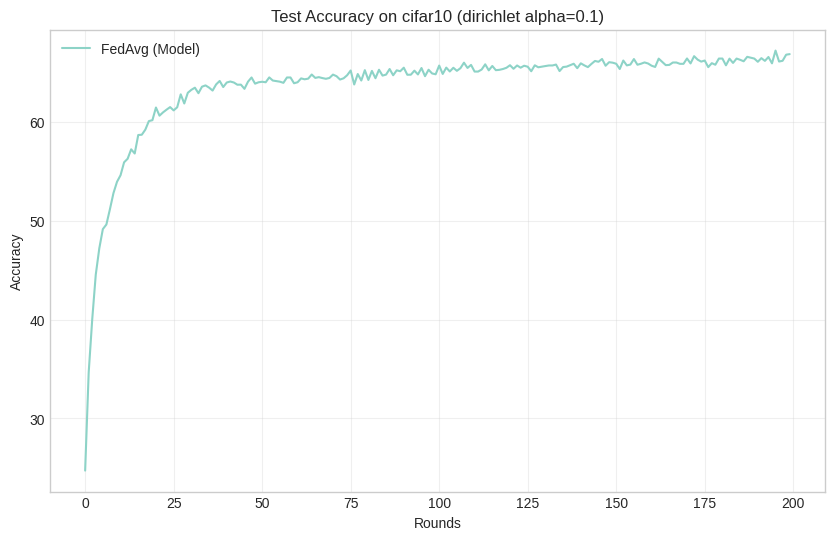

In [9]:
# Initialize Loader
loader = ResultLoader()

# Common Settings (Adjust these to match your run.sh)
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",  # Options: iid, dirichlet, pathological
    "num_clients": 10,
    "epochs": 10,
    "batch_size": 64,
    "lr": 0.01,
    "alpha": 0.1,    # For dirichlet
    "n_class": 2,    # For pathological
    "model": "cnn"   # For fedrep filename
}

# Define Experiments to Compare
# Format: "Label": (algo_name, {algo_specific_args})
experiments = {
    "FedAvg": ("fedavg", {}),

    # # Example for FedDPL (Replace values with what you actually ran)
    # "FedDPL": ("feddpl", {
    #     "lambda_": 10.0,
    #     "epoch_pln": 10,
    #     "lr_pln": 0.01,
    #     "batch_size_pln": 64,
    #     "feature_dim": 512,
    #     "depth_pln": 1,
    #     "width_pln": 512,
    #     "mode": "normal",
    #     "fixed_proto": 0,
    #     "init_emb": 0,
    #     "har": 0
    # }),

    # # Example for FedRep
    # "FedRep": ("fedrep", {
    #     "epochs_head": 5
    # })
}

# Load Data
results = {}
for label, (algo, kwargs) in experiments.items():
    # Merge common args with specific args
    args = common_args.copy()
    args.update(kwargs)

    results[label] = loader.load(algo, **args)

# Plot
title = f"Test Accuracy on {common_args['dataset']} ({common_args['partition']}" + (f" n_class={common_args['n_class']}" if common_args['partition'] == "pathological" else "") + (f" alpha={common_args['alpha']}" if common_args['partition'] == "dirichlet" else "") + ")"
plot_results(results, metric='acc', title=title)